In [6]:
import os
import cv2
import numpy as np
import glob
from skimage import io
from sklearn.model_selection import KFold
import kagglehub
from tqdm import tqdm
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Conv2DTranspose
from tensorflow.keras.layers import concatenate, BatchNormalization, Activation, add
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import tensorflow.keras.backend as K


print("Keras/TensorFlow version:", tf.__version__)
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Keras/TensorFlow version: 2.19.0
Num GPUs Available:  1


# Load data

In [7]:
base_input_path = "/kaggle/input/"

print("Đang quét tìm thư mục ISIC 2018...")
img_dirs = glob.glob(os.path.join(base_input_path, '**', '*ISIC2018_Task1-2_Training_Input*'), recursive=True)
msk_dirs = glob.glob(os.path.join(base_input_path, '**', '*ISIC2018_Task1_Training_GroundTruth*'), recursive=True)

if not img_dirs or not msk_dirs:
    print(f"Các thư mục/file hiện có: {os.listdir(base_input_path)}")
    raise FileNotFoundError("Không tìm thấy dữ liệu ISIC2018.")

img_dir = img_dirs[0]
msk_dir = msk_dirs[0]

img_paths = glob.glob(os.path.join(img_dir, '**', '*.jpg'), recursive=True)

print(f"Tìm thấy {len(img_paths)} ảnh gốc.")

Đang quét tìm thư mục ISIC 2018...
Tìm thấy 2594 ảnh gốc.


# Data & GT

In [8]:
import os
import shutil

# Đường dẫn thư mục làm việc của Kaggle
folder = '/kaggle/working'

# Liệt kê và xóa tất cả các file/thư mục con bên trong
for filename in os.listdir(folder):
    file_path = os.path.join(folder, filename)
    try:
        if os.path.isfile(file_path) or os.path.islink(file_path):
            os.unlink(file_path) # Xóa file hoặc link
        elif os.path.isdir(file_path):
            shutil.rmtree(file_path) # Xóa thư mục (như experiment_results)
    except Exception as e:
        print(f'Không thể xóa {file_path}. Lý do: {e}')

print("✅ Đã dọn dẹp sạch sẽ thư mục /kaggle/working!")

✅ Đã dọn dẹp sạch sẽ thư mục /kaggle/working!


In [9]:
X = []
Y = []

for img_path in tqdm(img_paths):
    base_name = os.path.basename(img_path).split('.')[0]
    
    mask_name = base_name + '_segmentation.png'
    
    # Tìm mask tương ứng
    found_masks = glob.glob(os.path.join(msk_dir, '**', mask_name), recursive=True)
    if len(found_masks) > 0:
        mask_path = found_masks[0]
        
        img = cv2.imread(img_path, cv2.IMREAD_COLOR)
        msk = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        
        if img is not None and msk is not None:
            # Resize về Width=256, Height=192
            resized_img = cv2.resize(img, (256, 192), interpolation=cv2.INTER_CUBIC)
            
            # Mask BẮT BUỘC dùng NEAREST để không sinh ra số âm
            resized_msk = cv2.resize(msk, (256, 192), interpolation=cv2.INTER_NEAREST)
            
            X.append(resized_img)
            Y.append(resized_msk)

X = np.array(X)
Y = np.array(Y)

X = X.reshape((X.shape[0], 192, 256, 3))
Y = Y.reshape((Y.shape[0], 192, 256, 1))

# Chuẩn hóa về [0, 1]
X = X / 255.0
Y = np.clip(Y / 255.0, 0, 1)
Y = np.round(Y, 0)

100%|██████████| 2594/2594 [05:39<00:00,  7.64it/s]


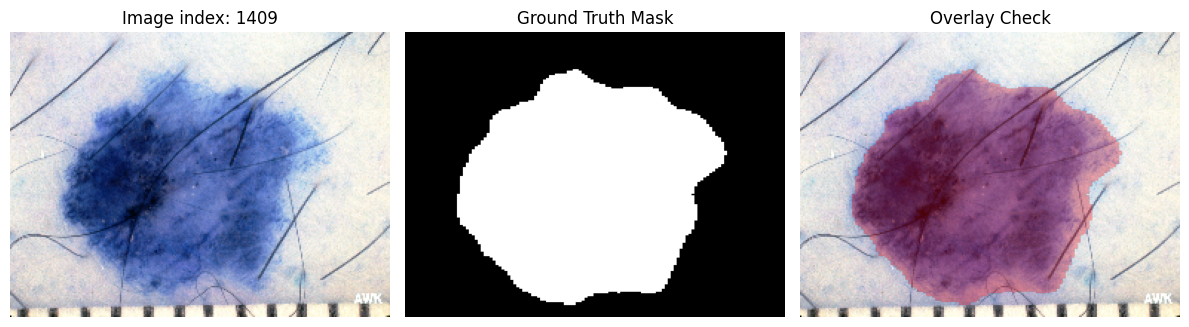

Kích thước ảnh X: (192, 256, 3)
Kích thước nhãn Y: (192, 256, 1)
Giá trị pixel duy nhất trong Y (nên là 0 và 1): [0. 1.]


In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Chọn một chỉ số ngẫu nhiên trong tập dữ liệu
idx = np.random.randint(0, len(X))

plt.figure(figsize=(12, 5))

# 1. Hiển thị ảnh gốc (X)
plt.subplot(1, 3, 1)
plt.imshow(X[idx])
plt.title(f'Image index: {idx}')
plt.axis('off')

# 2. Hiển thị mặt nạ (Y) - Mask
plt.subplot(1, 3, 2)
# Y có shape (192, 256, 1) nên cần squeeze() để về (192, 256) cho plt.imshow
plt.imshow(Y[idx].squeeze(), cmap='gray')
plt.title('Ground Truth Mask')
plt.axis('off')

# 3. Chồng mặt nạ lên ảnh gốc (Overlay) để kiểm tra độ khớp
plt.subplot(1, 3, 3)
plt.imshow(X[idx])
# Vẽ mask màu đỏ với độ trong suốt (alpha) là 0.3
mask = Y[idx].squeeze()
masked_img = np.ma.masked_where(mask == 0, mask)
plt.imshow(masked_img, cmap='autumn', alpha=0.3) 
plt.title('Overlay Check')
plt.axis('off')

plt.tight_layout()
plt.show()

print(f"Kích thước ảnh X: {X[idx].shape}")
print(f"Kích thước nhãn Y: {Y[idx].shape}")
print(f"Giá trị pixel duy nhất trong Y (nên là 0 và 1): {np.unique(Y[idx])}")

In [11]:
from sklearn.model_selection import train_test_split

# Chia train/test trên tập nhỏ này (ví dụ 80 ảnh train, 20 ảnh test)
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

print(f"X_train shape: {X_train.shape} ")
print(f"Y_train shape: {Y_train.shape} ")

X_train shape: (2075, 192, 256, 3) 
Y_train shape: (2075, 192, 256, 1) 


In [12]:
def jacard(y_true, y_pred):
    y_true_f = tf.cast(tf.reshape(y_true, [-1]), tf.float32)
    y_pred_f = tf.cast(tf.reshape(y_pred, [-1]), tf.float32)
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    union = tf.reduce_sum(y_true_f + y_pred_f - y_true_f * y_pred_f)
    return intersection / (union + K.epsilon())

# Unet Model

In [13]:
def conv_block(inputs, num_filters):
    x = Conv2D(num_filters, 3, padding="same", kernel_initializer="he_normal")(inputs)
    #x = BatchNormalization()(x)
    x = Activation("relu")(x)

    x = Conv2D(num_filters, 3, padding="same", kernel_initializer="he_normal")(x)
    #x = BatchNormalization()(x)
    x = Activation("relu")(x)
    return x

def build_unet_baseline(input_shape=(192, 256, 3)):
    inputs = Input(input_shape)

    # ENCODER
    s1 = conv_block(inputs, 32)
    p1 = MaxPooling2D((2, 2))(s1)

    s2 = conv_block(p1, 64)
    p2 = MaxPooling2D((2, 2))(s2)

    s3 = conv_block(p2, 128)
    p3 = MaxPooling2D((2, 2))(s3)

    s4 = conv_block(p3, 256)
    p4 = MaxPooling2D((2, 2))(s4)

    # BOTTLENECK 
    b5 = conv_block(p4, 512)

    # DECODER
    u6 = Conv2DTranspose(256, (2, 2), strides=(2, 2), padding="same")(b5)
    c6 = concatenate([u6, s4])
    d6 = conv_block(c6, 256)

    u7 = Conv2DTranspose(128, (2, 2), strides=(2, 2), padding="same")(d6)
    c7 = concatenate([u7, s3])
    d7 = conv_block(c7, 128)

    u8 = Conv2DTranspose(64, (2, 2), strides=(2, 2), padding="same")(d7)
    c8 = concatenate([u8, s2])
    d8 = conv_block(c8, 64)

    u9 = Conv2DTranspose(32, (2, 2), strides=(2, 2), padding="same")(d8)
    c9 = concatenate([u9, s1])
    d9 = conv_block(c9, 32)

    outputs = Conv2D(1, (1, 1), activation="sigmoid")(d9)

    model = Model(inputs, outputs, name="UNet_Baseline")
    return model

# MultiResUnet Model

In [14]:
def conv2d_bn(x, filters, num_row, num_col, padding='same', strides=(1, 1), activation='relu', name=None):
    x = Conv2D(filters, (num_row, num_col), strides=strides, padding=padding, use_bias=False)(x)
    x = BatchNormalization(axis=3, scale=False)(x)
    if activation is not None:
        x = Activation(activation, name=name)(x)
    return x

def trans_conv2d_bn(x, filters, num_row, num_col, padding='same', strides=(2, 2), name=None):
    x = Conv2DTranspose(filters, (num_row, num_col), strides=strides, padding=padding)(x)
    x = BatchNormalization(axis=3, scale=False)(x)
    return x

def MultiResBlock(U, inp, alpha=1.67):
    W = alpha * U
    shortcut = inp
    shortcut = conv2d_bn(shortcut, int(W*0.167) + int(W*0.333) + int(W*0.5), 
                         1, 1, activation=None, padding='same')
    
    conv3x3 = conv2d_bn(inp, int(W*0.167), 3, 3, activation='relu', padding='same')
    conv5x5 = conv2d_bn(conv3x3, int(W*0.333), 3, 3, activation='relu', padding='same')
    conv7x7 = conv2d_bn(conv5x5, int(W*0.5), 3, 3, activation='relu', padding='same')
    
    out = concatenate([conv3x3, conv5x5, conv7x7], axis=3)
    out = BatchNormalization(axis=3)(out)
    
    out = add([shortcut, out])
    out = Activation('relu')(out)
    out = BatchNormalization(axis=3)(out)
    return out

def ResPath(filters, length, inp):
    shortcut = inp
    shortcut = conv2d_bn(shortcut, filters, 1, 1, activation=None, padding='same')
    out = conv2d_bn(inp, filters, 3, 3, activation='relu', padding='same')
    
    out = add([shortcut, out])
    out = Activation('relu')(out)
    out = BatchNormalization(axis=3)(out)
    
    for i in range(length - 1):
        shortcut = out
        shortcut = conv2d_bn(shortcut, filters, 1, 1, activation=None, padding='same')
        out = conv2d_bn(out, filters, 3, 3, activation='relu', padding='same')
        
        out = add([shortcut, out])
        out = Activation('relu')(out)
        out = BatchNormalization(axis=3)(out)
    return out


def build_multiresunet(height, width, n_channels):
    inputs = Input((height, width, n_channels))
    
    # ENCODER
    mresblock1 = MultiResBlock(32, inputs)
    pool1 = MaxPooling2D(pool_size=(2, 2))(mresblock1)
    mresblock1 = ResPath(32, 4, mresblock1)
    
    mresblock2 = MultiResBlock(32*2, pool1)
    pool2 = MaxPooling2D(pool_size=(2, 2))(mresblock2)
    mresblock2 = ResPath(32*2, 3, mresblock2)
    
    mresblock3 = MultiResBlock(32*4, pool2)
    pool3 = MaxPooling2D(pool_size=(2, 2))(mresblock3)
    mresblock3 = ResPath(32*4, 2, mresblock3)
    
    mresblock4 = MultiResBlock(32*8, pool3)
    pool4 = MaxPooling2D(pool_size=(2, 2))(mresblock4)
    mresblock4 = ResPath(32*8, 1, mresblock4)
    
    # BOTTLENECK
    mresblock5 = MultiResBlock(32*16, pool4)
    
    # DECODER
    up6 = concatenate([Conv2DTranspose(32*8, (2, 2), strides=(2, 2), padding='same')(mresblock5), 
                       mresblock4], axis=3)
    mresblock6 = MultiResBlock(32*8, up6)
    up7 = concatenate([Conv2DTranspose(32*4, (2, 2), strides=(2, 2), padding='same')(mresblock6), 
                       mresblock3], axis=3)
    mresblock7 = MultiResBlock(32*4, up7)
    
    up8 = concatenate([Conv2DTranspose(32*2, (2, 2), strides=(2, 2), padding='same')(mresblock7), 
                       mresblock2], axis=3)
    mresblock8 = MultiResBlock(32*2, up8)
    
    up9 = concatenate([Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(mresblock8), 
                       mresblock1], axis=3)
    mresblock9 = MultiResBlock(32, up9)
    
    # OUTPUT: Bắt buộc dùng Conv2D thuần để tránh lỗi Jaccard thấp do BatchNormalization scale=False
    conv10 = Conv2D(1, (1, 1), activation='sigmoid', name='final_output')(mresblock9)
    
    model = Model(inputs=[inputs], outputs=[conv10], name='MultiResUNet')
    return model

# CDRBNet Model

In [15]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Conv2DTranspose, concatenate, add, Activation, BatchNormalization, GlobalAveragePooling2D, Dense, Reshape, multiply
from tensorflow.keras.models import Model

def conv2d_bn(x, filters, num_row, num_col, padding='same', strides=(1, 1), activation='relu', name=None):
    x = Conv2D(filters, (num_row, num_col), strides=strides, padding=padding, use_bias=False)(x)
    x = BatchNormalization(axis=3, scale=False)(x)
    if activation is not None:
        x = Activation(activation, name=name)(x)
    return x

def MultiResBlock(U, inp, alpha=1.67):
    W = alpha * U
    shortcut = conv2d_bn(inp, int(W*0.167) + int(W*0.333) + int(W*0.5), 1, 1, activation=None, padding='same')
    
    conv3x3 = conv2d_bn(inp, int(W*0.167), 3, 3, activation='relu', padding='same')
    conv5x5 = conv2d_bn(conv3x3, int(W*0.333), 3, 3, activation='relu', padding='same')
    conv7x7 = conv2d_bn(conv5x5, int(W*0.5), 3, 3, activation='relu', padding='same')
    
    out = concatenate([conv3x3, conv5x5, conv7x7], axis=3)
    out = BatchNormalization(axis=3)(out)
    
    out = add([shortcut, out])
    out = Activation('relu')(out)
    out = BatchNormalization(axis=3)(out)
    return out

def CDRB_Path(filters, length, inp):
    """
    Nâng cấp từ ResPath: 
    - Dense Connections: Giữ lại đặc trưng đa cấp độ.
    - Controller (Lambda): Gating mechanism để loại bỏ nhiễu thông tin.
    """
    def controller(feat):
        f = feat.shape[-1]
        # Squeeze & Excitation style gating
        avg_pool = GlobalAveragePooling2D()(feat)
        gate = Dense(f // 4, activation='relu')(avg_pool)
        lmbda = Dense(f, activation='sigmoid')(gate)
        return Reshape((1, 1, f))(lmbda)

    x_list = [inp]
    
    # Chu kỳ Dense Connections
    for i in range(length):
        # Nối tất cả layer trước đó (Dense)
        current_in = concatenate(x_list, axis=3) if len(x_list) > 1 else x_list[0]
        
        shortcut = conv2d_bn(current_in, filters, 1, 1, activation=None)
        out = conv2d_bn(current_in, filters, 3, 3, activation='relu')
        
        res = add([shortcut, out])
        res = Activation('relu')(res)
        res = BatchNormalization(axis=3)(res)
        x_list.append(res)
    
    # Lấy đặc trưng cuối cùng và nén về số lượng filters yêu cầu
    final_features = conv2d_bn(concatenate(x_list, axis=3), filters, 1, 1, activation='relu')
    
    # Áp dụng bộ điều khiển Lambda
    lmbda = controller(final_features)
    controlled_out = multiply([final_features, lmbda])
    
    return controlled_out

# --- 3. BUILD MODEL: CDRB-MultiResUNet ---
def build_cdrb_multiresunet(height, width, n_channels):
    inputs = Input((height, width, n_channels))
    
    # ENCODER
    m1 = MultiResBlock(32, inputs)
    p1 = MaxPooling2D(pool_size=(2, 2))(m1)
    s1 = CDRB_Path(32, 4, m1) # Skip connection 1 được kiểm soát
    
    m2 = MultiResBlock(64, p1)
    p2 = MaxPooling2D(pool_size=(2, 2))(m2)
    s2 = CDRB_Path(64, 3, m2)
    
    m3 = MultiResBlock(128, p2)
    p3 = MaxPooling2D(pool_size=(2, 2))(m3)
    s3 = CDRB_Path(128, 2, m3)
    
    m4 = MultiResBlock(256, p3)
    p4 = MaxPooling2D(pool_size=(2, 2))(m4)
    s4 = CDRB_Path(256, 1, m4)
    
    # BOTTLENECK
    b5 = MultiResBlock(512, p4)
    
    # DECODER
    up6 = concatenate([Conv2DTranspose(256, (2, 2), strides=(2, 2), padding='same')(b5), s4], axis=3)
    m6 = MultiResBlock(256, up6)
    
    up7 = concatenate([Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(m6), s3], axis=3)
    m7 = MultiResBlock(128, up7)
    
    up8 = concatenate([Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(m7), s2], axis=3)
    m8 = MultiResBlock(64, up8)
    
    up9 = concatenate([Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(m8), s1], axis=3)
    m9 = MultiResBlock(32, up9)
    
    # OUTPUT
    conv10 = Conv2D(1, (1, 1), activation='sigmoid', name='final_output')(m9)
    
    model = Model(inputs=[inputs], outputs=[conv10], name='CDRB_MultiResUNet')
    return model

In [16]:
import os
import logging

# Tắt các cảnh báo từ hệ thống TensorFlow (0: Tất cả, 1: Bỏ Info, 2: Bỏ Warning, 3: Chỉ hiện Error)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 

# Tắt các cảnh báo từ thư viện absl (thường gây ra các dòng đỏ về CUDA timer)
import absl.logging
absl.logging.set_verbosity(absl.logging.ERROR)

# Tắt log từ Python logger của TensorFlow
import tensorflow as tf
tf.get_logger().setLevel('ERROR')
tf.autograph.set_verbosity(0)


In [18]:
import numpy as np
import pandas as pd
import pickle
import os
import gc  # Thư viện dọn rác hệ thống
from sklearn.model_selection import KFold
from tensorflow.keras import backend as K
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

def run_subset_experiment(X_subset, Y_subset, n_splits=5, epochs=5, batch_size=4):
    save_dir = "test_experiment_results_3"
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)
        
    final_report = []

    for model_name in ['MultiResUNet','CDRB']:
        print(f"\n🚀 ĐANG CHẠY THÍ NGHIỆM: {model_name.upper()}")
        kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
        scores = []
        model_history_log = {} 
        
        for fold, (train_idx, val_idx) in enumerate(kf.split(X_subset), 1):
            print(f"\n--- {model_name.upper()} | Fold {fold}/{n_splits} ---")
            
            # GIẢI PHÁP TỐI ƯU VRAM 1: Xóa session cũ và giải phóng rác
            K.clear_session()
            gc.collect() 

            # Khởi tạo model
            if model_name == 'MultiResUnet':
                model = build_multiresunet(192, 256, 3)
            else:
                model = build_cdrb_multiresunet(192, 256, 3)
            
            model.compile(optimizer='adam', loss='binary_crossentropy', metrics=[jacard])
            
            weight_path = os.path.join(save_dir, f"{model_name}_f{fold}.weights.h5")
            
          
            callbacks = [
                ModelCheckpoint(weight_path, save_best_only=True, monitor='val_jacard', mode='max', verbose=0),
                EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
            ]
            
            history = model.fit(
                X_subset[train_idx], Y_subset[train_idx], 
                validation_data=(X_subset[val_idx], Y_subset[val_idx]),
                batch_size=batch_size, 
                epochs=epochs, 
                callbacks=callbacks, 
                verbose=1
            )
            
            model_history_log[f'fold_{fold}'] = history.history
            best_jaccard = max(history.history['val_jacard'])
            scores.append(best_jaccard)
            print(f"✅ Fold {fold} xong. Jaccard cao nhất: {best_jaccard*100:.2f}%")
            
            # GIẢI PHÁP TỐI ƯU VRAM 2: Xóa model sau khi dùng xong mỗi fold
            del model
            K.clear_session()
            gc.collect()

        # Lưu History
        history_path = os.path.join(save_dir, f"{model_name}_full_history.pkl")
        with open(history_path, 'wb') as f:
            pickle.dump(model_history_log, f)
            
        # Tìm Fold tốt nhất để Duy biết đường mà load
        best_f_idx = np.argmax(scores) + 1
        mean_s = np.mean(scores)
        std_s = np.std(scores)
        
        final_report.append({
            'Model': model_name.upper(),
            'Mean_Jaccard': f"{mean_s*100:.2f}%",
            'Std_Dev': f"{std_s*100:.2f}%",
            'Best_Fold': f"Fold {best_f_idx}",
            'Best_Score': f"{scores[best_f_idx-1]*100:.2f}%",
            'All_Folds': [f"{s*100:.2f}%" for s in scores]
        })
        
        print(f"\n📊 KẾT QUẢ {model_name.upper()}: {mean_s*100:.2f}% ± {std_s*100:.2f}%")
        print(f"🏆 Fold xịn nhất: Fold {best_f_idx} ({scores[best_f_idx-1]*100:.2f}%)")

    df_report = pd.DataFrame(final_report)
    df_report.to_csv(os.path.join(save_dir, "final_experiment_report.csv"), index=False)
    
    print(f"\n" + "="*40)
    print(f"✅ THÍ NGHIỆM HOÀN TẤT!")
    print(f"📍 Kết quả lưu tại: {save_dir}")
    print(f"📍 Fold tốt nhất của MultiResUNet là: {df_report.iloc[1]['Best_Fold']}")
    print(f"📍 Đường dẫn: {save_dir}/MultiResUNet_f{best_f_idx}.weights.h5")
    print("="*40)
    
    return df_report

# Chạy test 
test_results = run_subset_experiment(X_train, Y_train, n_splits=3, epochs=50, batch_size=4)


🚀 ĐANG CHẠY THÍ NGHIỆM: MULTIRESUNET

--- MULTIRESUNET | Fold 1/3 ---


I0000 00:00:1775456636.628645      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Epoch 1/50


I0000 00:00:1775456676.043645     141 service.cc:152] XLA service 0x79e208002f40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775456676.043718     141 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1775456682.156098     141 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-04-06 06:24:47.526008: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-06 06:24:47.766886: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  1/346 ━━━━━━━━━━━━━━━━━━━━ 8:18:32 87s/step - jacard: 0.1941 - loss: 0.8267

I0000 00:00:1775456729.121542     141 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


345/346 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - jacard: 0.3591 - loss: 0.4136

2026-04-06 06:26:18.241502: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-06 06:26:18.482155: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


346/346 ━━━━━━━━━━━━━━━━━━━━ 189s 295ms/step - jacard: 0.3594 - loss: 0.4132 - val_jacard: 0.3837 - val_loss: 0.3915
Epoch 2/50
346/346 ━━━━━━━━━━━━━━━━━━━━ 46s 134ms/step - jacard: 0.4885 - loss: 0.2467 - val_jacard: 0.4957 - val_loss: 0.3893
Epoch 3/50
346/346 ━━━━━━━━━━━━━━━━━━━━ 46s 133ms/step - jacard: 0.5170 - loss: 0.2395 - val_jacard: 0.5390 - val_loss: 0.2047
Epoch 4/50
346/346 ━━━━━━━━━━━━━━━━━━━━ 46s 133ms/step - jacard: 0.5623 - loss: 0.1966 - val_jacard: 0.5629 - val_loss: 0.1803
Epoch 5/50
346/346 ━━━━━━━━━━━━━━━━━━━━ 46s 132ms/step - jacard: 0.5848 - loss: 0.1815 - val_jacard: 0.5421 - val_loss: 0.2114
Epoch 6/50
346/346 ━━━━━━━━━━━━━━━━━━━━ 46s 133ms/step - jacard: 0.5814 - loss: 0.1861 - val_jacard: 0.5719 - val_loss: 0.1884
Epoch 7/50
346/346 ━━━━━━━━━━━━━━━━━━━━ 45s 131ms/step - jacard: 0.6102 - loss: 0.1795 - val_jacard: 0.5613 - val_loss: 0.1994
Epoch 8/50
346/346 ━━━━━━━━━━━━━━━━━━━━ 45s 131ms/step - jacard: 0.6304 - loss: 0.1567 - val_jacard: 0.4988 - val_loss: 0

In [ ]:
# import os
# import pickle
# import matplotlib.pyplot as plt
# import numpy as np

# # BƯỚC 1: Dán cái path Duy vừa copy vào đây và XOÁ tên file ở cuối
# # Giữ lại đến chữ /test_experiment_results thôi nhé
# data_path = "/kaggle/input/notebooks/khanhduynguyenhuu/demo-unet-isic-2018/test_experiment_results_2"
# # BƯỚC 2: Kiểm tra xem có thấy file không
# if os.path.exists(data_path):
#     print("✅ Đã kết nối thư mục thành công!")
#     print("📁 Danh sách file tìm thấy:", os.listdir(data_path), "...") # In thử 3 file đầu
# else:
#     print("❌ Đường dẫn sai rồi Duy ơi! Hãy kiểm tra lại nhé.")

# # BƯỚC 3: Vẽ biểu đồ
# def draw_jaccard_final(save_dir):
#     plt.figure(figsize=(10, 6))
    
#     for m_name, color, label in zip(['unet', 'MultiResUNet'], ['#e74c3c', '#3498db'], ['U-Net', 'MultiResUNet']):
#         path = os.path.join(save_dir, f"{m_name}_full_history.pkl")
        
#         if not os.path.exists(path):
#             print(f"⚠️ Không tìm thấy file history cho {m_name}")
#             continue
            
#         with open(path, 'rb') as f:
#             log = pickle.load(f)
        
#         # Xử lý dữ liệu 5 folds
#         all_vals = [log[f]['val_jacard'] for f in log]
#         min_len = min(len(h) for h in all_vals)
#         truncated_vals = np.array([h[:min_len] for h in all_vals])
        
#         mean_val = np.mean(truncated_vals, axis=0) * 100
#         std_val = np.std(truncated_vals, axis=0) * 100
#         epochs = range(1, min_len + 1)
        
#         plt.plot(epochs, mean_val, label=label, color=color, linewidth=2)
#         plt.fill_between(epochs, mean_val - std_val, mean_val + std_val, color=color, alpha=0.15)
    
#     plt.title("Jaccard Index Comparison (ISIC-2018 Data)", fontsize=14)
#     plt.xlabel("Epochs"); plt.ylabel("Validation Jaccard (%)")
#     plt.legend(loc='lower right'); plt.grid(True, linestyle='--', alpha=0.5)
#     plt.show()

# # Thực hiện vẽ
# draw_jaccard_final(data_path)

In [ ]:
# import cv2
# import matplotlib.pyplot as plt
# import numpy as np
# from tensorflow.keras.models import load_model

# # 1. Giữ nguyên các hàm helper (đã ổn)
# def get_contours(mask):
#     mask = (mask > 0.5).astype(np.uint8)
#     contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
#     return contours

# def visualize_results(X_test_data, Y_test_data, model_u, model_m, num_samples=3):
#     for i in range(num_samples):
#         # Lấy ngẫu nhiên ảnh trong tập TEST thật (518 ảnh)
#         idx = np.random.randint(0, len(X_test_data))
#         img = X_test_data[idx]
#         gt = Y_test_data[idx].squeeze()
        
#         pred_u = model_u.predict(X_test_data[idx:idx+1], verbose=0)[0].squeeze()
#         pred_m = model_m.predict(X_test_data[idx:idx+1], verbose=0)[0].squeeze()
        
#         j_u = np.sum((pred_u>0.5) * gt) / (np.sum((pred_u>0.5) + gt - (pred_u>0.5)*gt) + 1e-7)
#         j_m = np.sum((pred_m>0.5) * gt) / (np.sum((pred_m>0.5) + gt - (pred_m>0.5)*gt) + 1e-7)

#         plt.figure(figsize=(20, 10))
#         plt.subplot(1, 5, 1); plt.imshow(img); plt.title("Input Image"); plt.axis('off')
#         plt.subplot(1, 5, 2); plt.imshow(gt, cmap='gray'); plt.title("Ground Truth"); plt.axis('off')
#         plt.subplot(1, 5, 3); plt.imshow(pred_m > 0.5, cmap='gray'); plt.title(f"MultiResUNet\nJ.I: {j_m:.4f}"); plt.axis('off')
#         plt.subplot(1, 5, 4); plt.imshow(pred_u > 0.5, cmap='gray'); plt.title(f"U-Net\nJ.I: {j_u:.4f}"); plt.axis('off')
        
#         plt.subplot(1, 5, 5); plt.imshow(img)
#         for mask, col, label in zip([gt, pred_m, pred_u], ['lime', 'blue', 'red'], ['GT', 'MultiRes', 'UNet']):
#             cnts = get_contours(mask)
#             for c in cnts:
#                 plt.plot(c[:,0,0], c[:,0,1], color=col, linewidth=2)
#         plt.title("Comparison\n(Green:GT, Blue:Multi, Red:UNet)"); plt.axis('off')
#         plt.show()

# # --- PHẦN CẦN THAY ĐỔI THEO KẾT QUẢ THẬT ---
# # Duy hãy thay 'f4' bằng fold nào đạt điểm cao nhất trong file report nhé
# best_fold = 4 
# save_dir = "final_experiment_results_2"

# m_u = load_model(f'/kaggle/input/notebooks/khanhduynguyenhuu/demo-unet-isic-2018/test_experiment_results_2/unet_f3.weights.h5', custom_objects={'jacard': jacard})
# m_m = load_model(f'/kaggle/input/notebooks/khanhduynguyenhuu/demo-unet-isic-2018/test_experiment_results_2/MultiResUNet_f4.weights.h5', custom_objects={'jacard': jacard})

# # Chạy trên tập TEST thật (X_test, Y_test từ train_test_split)
# visualize_results(X_test, Y_test, m_u, m_m, num_samples=5)